# (Solution) Word clouds for Python-Programmers

In this notebook we will instruct an AI-assistant to generate code for us to draw [Wordcloud plots](https://github.com/amueller/word_cloud) from a speech given and published by Anthony Albanese MP, Prime Minister of Australia, under [CC-BY 4.0](https://pmtranscripts.pmc.gov.au/copyright) license.

The AI-assistant [Bob](https://github.com/haesleinhuepf/bia-bob) is built-in to Jupyter lab and can be instructed by starting a conversation with `%%bob` and then outlining below what needs to be done. Before we can use it, we need to [initialize](https://github.com/haesleinhuepf/bia-bob#installation) it. Here we use the LLM-server at the compute center ZIH at University of Technology TU Dresden.

In [ ]:
# load secret API key. You must unpack the contents of api_key.zip 
# into the same folder before going ahead.
from dotenv import load_dotenv
load_dotenv()

import os
from bia_bob import bob
bob.initialize(endpoint='https://llm.scads.ai/v1', model='openai/gpt-oss-120b', api_key=os.environ.get('SCADSAI_API_KEY'))

In [1]:
%%bob
Load "Speech_Australian_PM.txt" and draw a wordcloud of it.

Load the text file and generate a word cloud visualization from its content.



In [2]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [3]:
# Load text
with open("Speech_Australian_PM.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [4]:
# Generate word cloud
stopwords = set(STOPWORDS)
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords).generate(text)

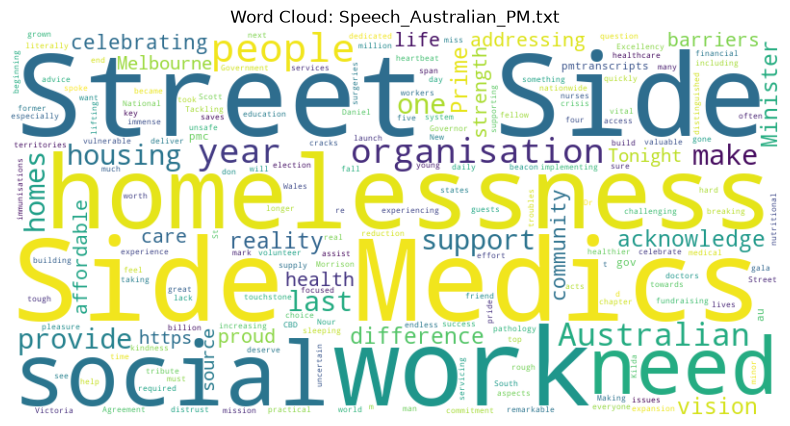

In [5]:
# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: Speech_Australian_PM.txt")
plt.show()

In [6]:
%%bob
Write Python code that uses the OpenAI-API to translate the content of the file to German and draw a word-cloud of the translation.
As OpenAI-compatible server use "https://llm.scads.ai/v1" and use the API key stored in the environment variable "SCADSAI_API_KEY".

Translate the loaded text to German using an OpenAI-compatible API endpoint, then generate and display a word cloud from the translated text.



In [7]:
import os
from openai import OpenAI

In [8]:
# Set up client
client = OpenAI(
    base_url="https://llm.scads.ai/v1",
    api_key=os.environ["SCADSAI_API_KEY"]
)

In [9]:
# Translate text to German
response = client.chat.completions.create(
    model="meta-llama/Llama-3.3-70B-Instruct",
    messages=[
        {"role": "system", "content": "You are a professional translator. Translate the given text to German, output only the translation."},
        {"role": "user", "content": text}
    ]
)

translated_text = response.choices[0].message.content

In [10]:
# Generate word cloud from translated text
wordcloud_de = WordCloud(width=800, height=400, background_color="white").generate(translated_text)

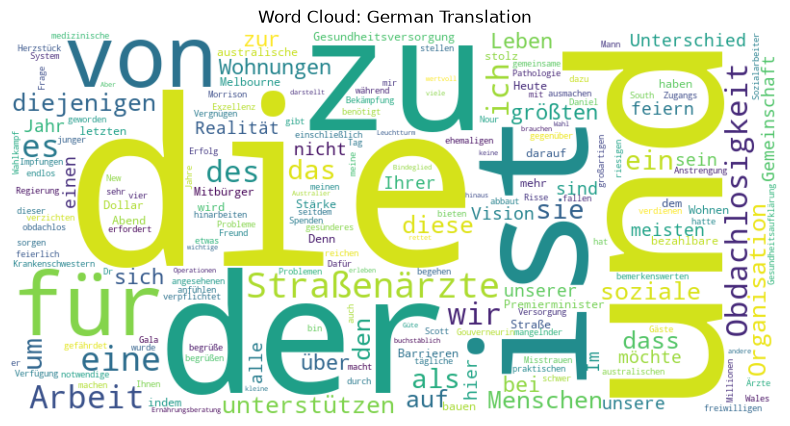

In [11]:
# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_de, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud: German Translation")
plt.show()